In [102]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

In [103]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,20.879744,82.002744,202.935536,6.502985,69.30,79.50000,94.4400,0.63,Loamy Soil,rice
1,21.770462,80.319644,226.655537,7.038096,72.02,141.82400,141.6978,1.40,Loamy Soil,rice
2,23.004459,82.320763,263.964248,7.633568,77.77,59.39000,81.8900,1.80,Peaty Soil,rice
3,26.491096,80.283629,242.864034,6.980401,78.65,147.45895,142.9430,1.43,Loamy Soil,rice
4,20.280071,81.604873,262.717340,7.628473,73.98,68.95000,95.7400,1.75,Peaty Soil,rice


In [104]:
df.shape

(3100, 10)

In [105]:
df.columns

Index(['Temperature', 'Humidity', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop'],
      dtype='str')

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Humidity     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
dtypes: float64(8), str(2)
memory usage: 297.1 KB


In [107]:
df.describe()

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.105071,66.005004,110.212026,6.368656,61.236056,70.195388,69.553449,1.478071
std,7.545380,23.996884,63.894459,0.801479,8.391950,34.897833,29.464613,0.577143
min,9.944995,10.199589,20.757078,3.686162,50.580000,32.896500,41.841500,0.500000
25%,22.810495,55.366047,64.997024,5.896095,55.395000,45.255000,50.760000,0.980000
50%,26.087226,68.918967,97.057093,6.342518,59.265000,57.640000,56.895000,1.470000
75%,29.343867,84.446524,141.210784,6.839783,64.962500,82.212500,73.592500,1.980000
max,54.779935,99.646348,385.086491,9.407343,96.197500,149.099313,149.224250,2.500000


In [108]:

df.shape

(3100, 10)

In [109]:

df.columns

Index(['Temperature', 'Humidity', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop'],
      dtype='str')

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Humidity     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
dtypes: float64(8), str(2)
memory usage: 297.1 KB


In [111]:
df.describe()

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.105071,66.005004,110.212026,6.368656,61.236056,70.195388,69.553449,1.478071
std,7.545380,23.996884,63.894459,0.801479,8.391950,34.897833,29.464613,0.577143
min,9.944995,10.199589,20.757078,3.686162,50.580000,32.896500,41.841500,0.500000
25%,22.810495,55.366047,64.997024,5.896095,55.395000,45.255000,50.760000,0.980000
50%,26.087226,68.918967,97.057093,6.342518,59.265000,57.640000,56.895000,1.470000
75%,29.343867,84.446524,141.210784,6.839783,64.962500,82.212500,73.592500,1.980000
max,54.779935,99.646348,385.086491,9.407343,96.197500,149.099313,149.224250,2.500000


In [112]:
df.isnull().sum()

Temperature    0
Humidity       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
dtype: int64

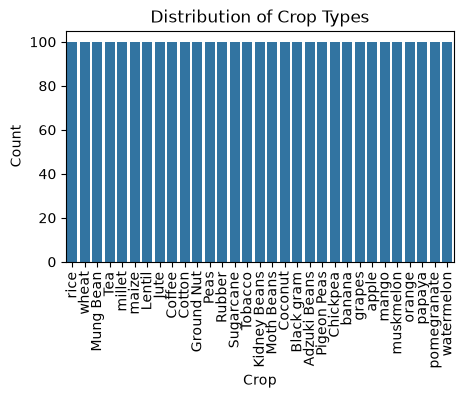

In [113]:
plt.figure(figsize=(5,3))

sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)

plt.xticks(rotation=90)
plt.title("Distribution of Crop Types")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.show()

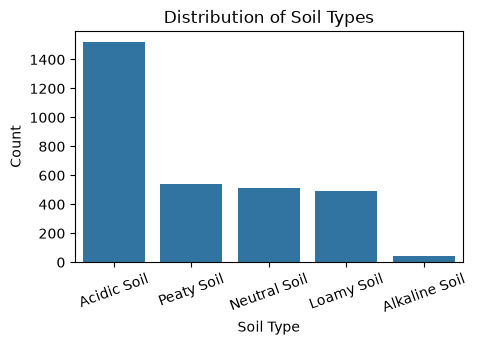

In [114]:
plt.figure(figsize=(5,3))

sns.countplot(data=df, x="Soil", order=df["Soil"].value_counts().index)

plt.title("Distribution of Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

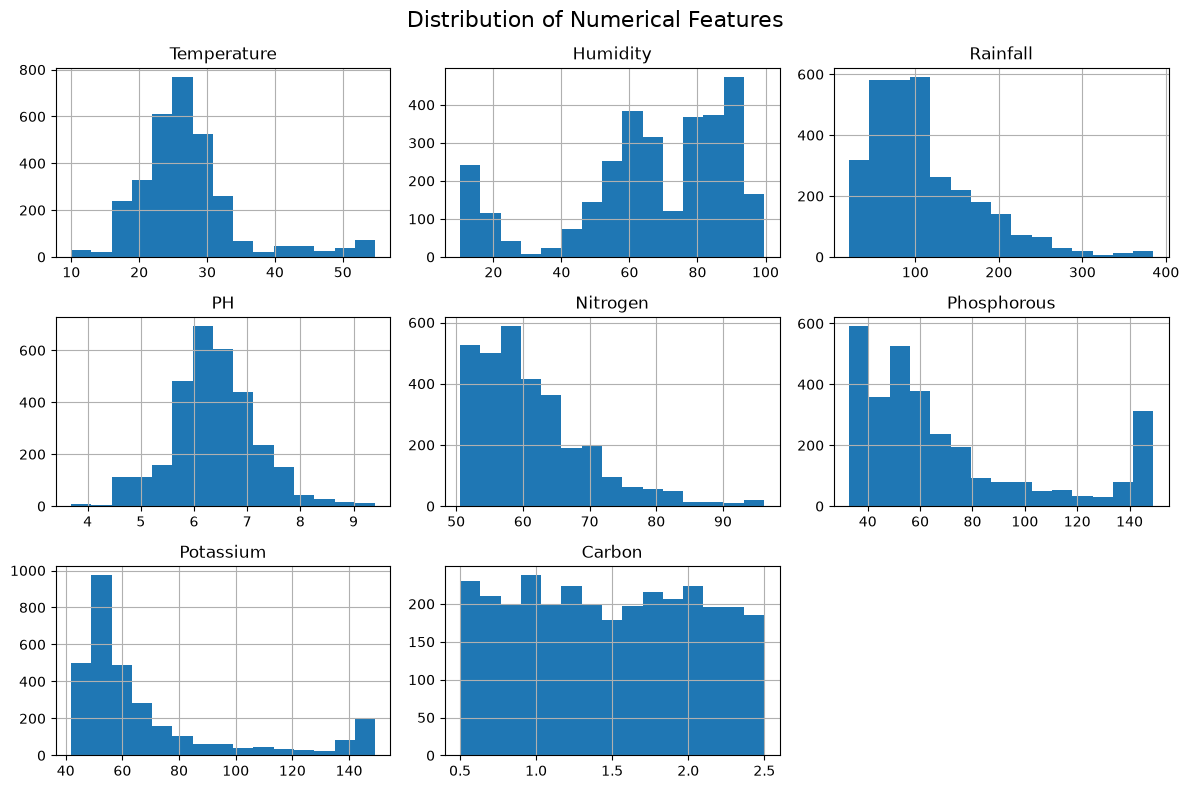

In [115]:
df.hist(figsize=(12, 8), bins=15)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

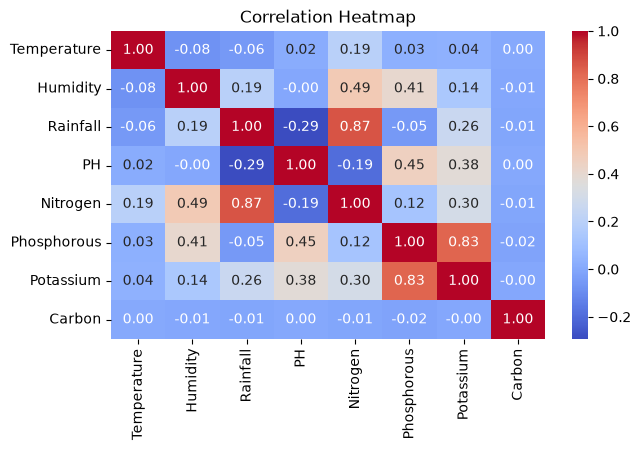

In [116]:
correlation = df.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(7, 4))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [117]:
X = df.drop("Crop", axis=1)
y = df["Crop"]

In [118]:
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (3100, 9)
Target (y): (3100,)


In [119]:

X = pd.get_dummies(X, columns=["Soil"], dtype=int)

In [120]:
X.head()

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil_Acidic Soil,Soil_Alkaline Soil,Soil_Loamy Soil,Soil_Neutral Soil,Soil_Peaty Soil
0,20.879744,82.002744,202.935536,6.502985,69.30,79.50000,94.4400,0.63,0,0,1,0,0
1,21.770462,80.319644,226.655537,7.038096,72.02,141.82400,141.6978,1.40,0,0,1,0,0
2,23.004459,82.320763,263.964248,7.633568,77.77,59.39000,81.8900,1.80,0,0,0,0,1
3,26.491096,80.283629,242.864034,6.980401,78.65,147.45895,142.9430,1.43,0,0,1,0,0
4,20.280071,81.604873,262.717340,7.628473,73.98,68.95000,95.7400,1.75,0,0,0,0,1


In [121]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [122]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (2480, 13)
Testing Features: (620, 13)
Training Labels: (2480,)
Testing Labels: (620,)


In [123]:
dt_model = DecisionTreeClassifier(random_state=42)

In [124]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [125]:

y_pred = dt_model.predict(X_test)

In [126]:

comparison = pd.DataFrame({
    "Actual Crop": y_test.values,
    "Predicted Crop": y_pred
})

comparison.head(10)

,Actual Crop,Predicted Crop
0,Jute,Jute
1,pomegranate,pomegranate
2,Black gram,Black gram
3,Moth Beans,Moth Beans
4,Peas,Peas
5,Pigeon Peas,Pigeon Peas
6,mango,mango
7,Tobacco,Tobacco
8,Tea,Tea
9,Coconut,Coconut


In [127]:

accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {accuracy:.2%}")

Decision Tree Accuracy: 94.19%


In [128]:
cm = confusion_matrix(y_test, y_pred)

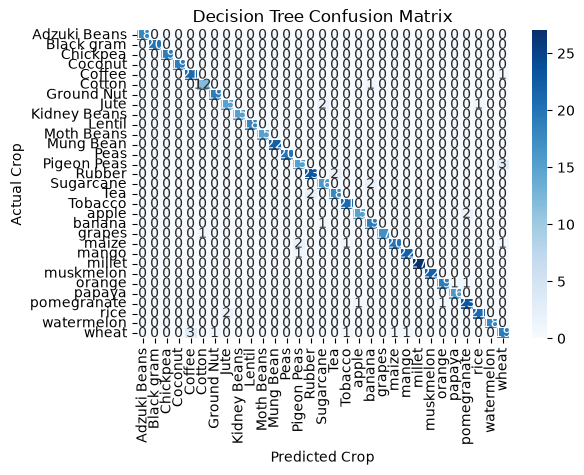

In [129]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.show()

In [130]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

Adzuki Beans       1.00      1.00      1.00        18
  Black gram       1.00      1.00      1.00        20
    Chickpea       1.00      1.00      1.00        19
     Coconut       1.00      1.00      1.00        19
      Coffee       0.88      0.95      0.91        22
      Cotton       0.92      0.92      0.92        13
  Ground Nut       0.95      1.00      0.97        19
        Jute       0.88      0.83      0.86        18
Kidney Beans       1.00      1.00      1.00        15
      Lentil       1.00      1.00      1.00        18
  Moth Beans       1.00      1.00      1.00        15
   Mung Bean       1.00      1.00      1.00        22
        Peas       1.00      1.00      1.00        20
 Pigeon Peas       0.83      0.83      0.83        18
      Rubber       0.92      0.92      0.92        25
   Sugarcane       0.84      0.89      0.86        18
         Tea       0.90      0.90      0.90        20
     Tobacco       0.91    

In [131]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [132]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [133]:
rf_pred = rf_model.predict(X_test)

In [134]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 96.61%


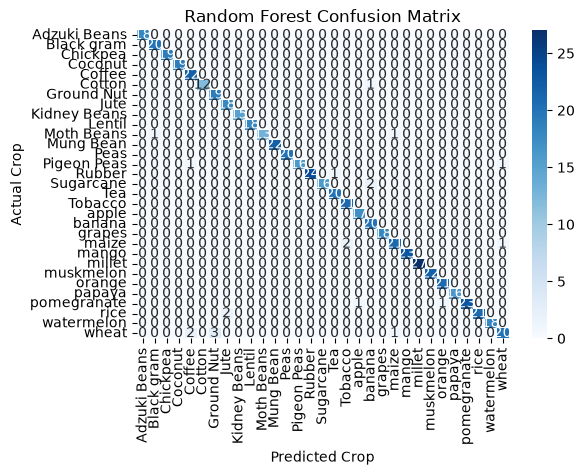

In [135]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.show()

In [136]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

Adzuki Beans       1.00      1.00      1.00        18
  Black gram       0.95      1.00      0.98        20
    Chickpea       1.00      1.00      1.00        19
     Coconut       1.00      1.00      1.00        19
      Coffee       0.88      1.00      0.94        22
      Cotton       1.00      0.92      0.96        13
  Ground Nut       0.86      1.00      0.93        19
        Jute       0.90      1.00      0.95        18
Kidney Beans       1.00      1.00      1.00        15
      Lentil       1.00      1.00      1.00        18
  Moth Beans       1.00      0.87      0.93        15
   Mung Bean       1.00      1.00      1.00        22
        Peas       1.00      1.00      1.00        20
 Pigeon Peas       1.00      0.89      0.94        18
      Rubber       1.00      0.96      0.98        25
   Sugarcane       1.00      0.89      0.94        18
         Tea       0.95      1.00      0.98        20
     Tobacco       0.91    

In [137]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [138]:
scaler.fit_transform(X_train)

array([[-1.30691807, -2.18851378, -0.88173654, ..., -0.43328912,
        -0.43852901, -0.45088731],
       [ 0.57145683, -0.49745687,  0.54707307, ..., -0.43328912,
         2.28035085, -0.45088731],
       [ 0.3974568 , -0.66790962, -0.21839815, ..., -0.43328912,
        -0.43852901, -0.45088731],
       ...,
       [-1.21056458, -2.21537941, -0.87103714, ..., -0.43328912,
        -0.43852901,  2.21784905],
       [ 0.50862792,  0.16416333,  1.72469392, ..., -0.43328912,
        -0.43852901,  2.21784905],
       [-0.0879796 , -0.57773896,  1.05800835, ...,  2.30792777,
        -0.43852901, -0.45088731]], shape=(2480, 13))

In [139]:
scaler.transform(X_test)

array([[-0.02668835,  0.50615869,  0.94049531, ..., -0.43328912,
        -0.43852901, -0.45088731],
       [-1.14635664,  1.04542623, -0.00508884, ...,  2.30792777,
        -0.43852901, -0.45088731],
       [ 0.23746559, -0.0315532 , -0.74990614, ..., -0.43328912,
        -0.43852901,  2.21784905],
       ...,
       [-0.66317708,  1.18984253,  0.01562155, ..., -0.43328912,
        -0.43852901,  2.21784905],
       [-1.36581029, -2.19749726, -0.98836033, ..., -0.43328912,
         2.28035085, -0.45088731],
       [-1.49438024, -1.87708946, -0.23281005, ..., -0.43328912,
        -0.43852901,  2.21784905]], shape=(620, 13))

In [140]:
from sklearn.neighbors import KNeighborsClassifier

In [141]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [142]:
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](31,)","['Adzuki Beans','Black gram','Chickpea',...,'rice','watermelon','wheat']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [143]:
knn_pred = knn_model.predict(X_test_scaled)

In [144]:
knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"KNN Accuracy: {knn_accuracy:.2%}")

KNN Accuracy: 74.35%


In [145]:
from sklearn.linear_model import LogisticRegression

In [146]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [147]:
lr_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [148]:
lr_pred = lr_model.predict(X_test_scaled)

In [149]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

Logistic Regression Accuracy: 78.55%


In [150]:
rf_pred = rf_model.predict(X_test)

In [151]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 96.61%


In [152]:
dt_accuracy = accuracy_score(y_test, y_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)

model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "Logistic Regression"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        lr_accuracy
    ]
})

model_results["Accuracy (%)"] = model_results["Accuracy"] * 100

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Accuracy,Accuracy (%)
0,Random Forest,0.966129,96.612903
1,Decision Tree,0.941935,94.193548
2,Logistic Regression,0.785484,78.548387
3,K-Nearest Neighbors,0.743548,74.354839


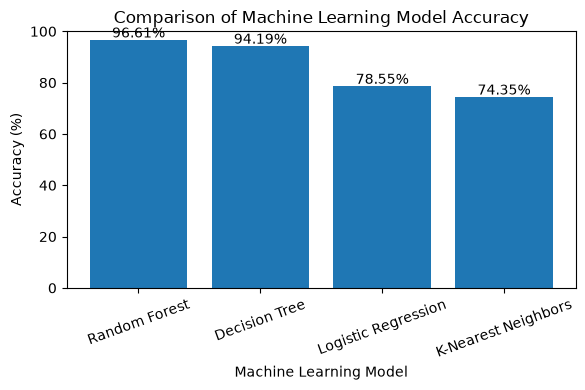

In [153]:
models = [
    "Random Forest",
    "Decision Tree",
    "Logistic Regression",
    "K-Nearest Neighbors"
]

accuracies = [
    96.61,
    94.19,
    78.55,
    74.35
]

plt.figure(figsize=(6, 4))

bars = plt.bar(models, accuracies)

plt.title("Comparison of Machine Learning Model Accuracy")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [154]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

Adzuki Beans       1.00      1.00      1.00        18
  Black gram       0.95      1.00      0.98        20
    Chickpea       1.00      1.00      1.00        19
     Coconut       1.00      1.00      1.00        19
      Coffee       0.88      1.00      0.94        22
      Cotton       1.00      0.92      0.96        13
  Ground Nut       0.86      1.00      0.93        19
        Jute       0.90      1.00      0.95        18
Kidney Beans       1.00      1.00      1.00        15
      Lentil       1.00      1.00      1.00        18
  Moth Beans       1.00      0.87      0.93        15
   Mung Bean       1.00      1.00      1.00        22
        Peas       1.00      1.00      1.00        20
 Pigeon Peas       1.00      0.89      0.94        18
      Rubber       1.00      0.96      0.98        25
   Sugarcane       1.00      0.89      0.94        18
         Tea       0.95      1.00      0.98        20
     Tobacco       0.91    

In [155]:
X.columns.tolist()

['Temperature',
 'Humidity',
 'Rainfall',
 'PH',
 'Nitrogen',
 'Phosphorous',
 'Potassium',
 'Carbon',
 'Soil_Acidic Soil',
 'Soil_Alkaline Soil',
 'Soil_Loamy Soil',
 'Soil_Neutral Soil',
 'Soil_Peaty Soil']

In [156]:
def recommend_crop(temperature, humidity, rainfall, ph,
                   nitrogen, phosphorous, potassium, carbon, soil):

    input_data = {
        "Temperature": temperature,
        "Humidity": humidity,
        "Rainfall": rainfall,
        "PH": ph,
        "Nitrogen": nitrogen,
        "Phosphorous": phosphorous,
        "Potassium": potassium,
        "Carbon": carbon,
        "Soil_Acidic Soil": 0,
        "Soil_Alkaline Soil": 0,
        "Soil_Loamy Soil": 0,
        "Soil_Neutral Soil": 0,
        "Soil_Peaty Soil": 0
    }

    soil_column = "Soil_" + soil

    if soil_column not in input_data:
        print("Invalid soil type.")
        print("Choose: Acidic Soil, Alkaline Soil, Loamy Soil, Neutral Soil, or Peaty Soil")
        return

    input_data[soil_column] = 1

    input_df = pd.DataFrame([input_data])

    input_df = input_df[X.columns]

    prediction = rf_model.predict(input_df)

    return prediction[0]

In [157]:
result = recommend_crop(
    temperature=25,
    humidity=80,
    rainfall=200,
    ph=6.5,
    nitrogen=90,
    phosphorous=42,
    potassium=43,
    carbon=1.5,
    soil="Loamy Soil"
)

print("Recommended Crop:", result)

Recommended Crop: rice


In [158]:
test_cases = [
    {
        "temperature": 25,
        "humidity": 80,
        "rainfall": 200,
        "ph": 6.5,
        "nitrogen": 90,
        "phosphorous": 42,
        "potassium": 43,
        "carbon": 1.5,
        "soil": "Loamy Soil"
    },
    {
        "temperature": 22,
        "humidity": 75,
        "rainfall": 150,
        "ph": 6.0,
        "nitrogen": 80,
        "phosphorous": 40,
        "potassium": 40,
        "carbon": 1.2,
        "soil": "Peaty Soil"
    },
    {
        "temperature": 28,
        "humidity": 70,
        "rainfall": 100,
        "ph": 6.8,
        "nitrogen": 70,
        "phosphorous": 45,
        "potassium": 50,
        "carbon": 1.8,
        "soil": "Loamy Soil"
    }
]

for i, case in enumerate(test_cases, start=1):
    prediction = recommend_crop(**case)
    print(f"Test {i}: Recommended Crop = {prediction}")

Test 1: Recommended Crop = rice
Test 2: Recommended Crop = Moth Beans
Test 3: Recommended Crop = Pigeon Peas


In [159]:
temperature = widgets.FloatText(
    description="Temperature:",
    value=25
)

humidity = widgets.FloatText(
    description="Humidity:",
    value=80
)

rainfall = widgets.FloatText(
    description="Rainfall:",
    value=200
)

ph = widgets.FloatText(
    description="pH:",
    value=6.5
)

nitrogen = widgets.FloatText(
    description="Nitrogen:",
    value=90
)

phosphorous = widgets.FloatText(
    description="Phosphorous:",
    value=42
)

potassium = widgets.FloatText(
    description="Potassium:",
    value=43
)

carbon = widgets.FloatText(
    description="Carbon:",
    value=1.5
)

soil = widgets.Dropdown(
    options=[
        "Acidic Soil",
        "Alkaline Soil",
        "Loamy Soil",
        "Neutral Soil",
        "Peaty Soil"
    ],
    description="Soil:"
)

In [160]:
button = widgets.Button(
    description="Recommend Crop"
)

output = widgets.Output()

In [161]:
def on_button_clicked(b):
    with output:
        output.clear_output()
        
        result = recommend_crop(
            temperature.value,
            humidity.value,
            rainfall.value,
            ph.value,
            nitrogen.value,
            phosphorous.value,
            potassium.value,
            carbon.value,
            soil.value
        )
        
        print("Recommended Crop:", result)

button.on_click(on_button_clicked)

In [162]:
display(
    temperature,
    humidity,
    rainfall,
    ph,
    nitrogen,
    phosphorous,
    potassium,
    carbon,
    soil,
    button,
    output
)

FloatText(value=25.0, description='Temperature:')

FloatText(value=80.0, description='Humidity:')

FloatText(value=200.0, description='Rainfall:')

FloatText(value=6.5, description='pH:')

FloatText(value=90.0, description='Nitrogen:')

FloatText(value=42.0, description='Phosphorous:')

FloatText(value=43.0, description='Potassium:')

FloatText(value=1.5, description='Carbon:')

Dropdown(description='Soil:', options=('Acidic Soil', 'Alkaline Soil', 'Loamy Soil', 'Neutral Soil', 'Peaty So…

Button(description='Recommend Crop', style=ButtonStyle())

Output()

In [163]:
temperature = widgets.FloatText(
    description="Temperature:",
    value=25
)

humidity = widgets.FloatText(
    description="Humidity:",
    value=80
)

rainfall = widgets.FloatText(
    description="Rainfall:",
    value=200
)

ph = widgets.FloatText(
    description="pH:",
    value=6.5
)

nitrogen = widgets.FloatText(
    description="Nitrogen:",
    value=90
)

phosphorous = widgets.FloatText(
    description="Phosphorous:",
    value=42
)

potassium = widgets.FloatText(
    description="Potassium:",
    value=43
)

carbon = widgets.FloatText(
    description="Carbon:",
    value=1.5
)

soil = widgets.Dropdown(
    options=[
        "Acidic Soil",
        "Alkaline Soil",
        "Loamy Soil",
        "Neutral Soil",
        "Peaty Soil"
    ],
    description="Soil:"
)

In [164]:
display(
    temperature,
    humidity,
    rainfall,
    ph,
    nitrogen,
    phosphorous,
    potassium,
    carbon,
    soil
)

FloatText(value=25.0, description='Temperature:')

FloatText(value=80.0, description='Humidity:')

FloatText(value=200.0, description='Rainfall:')

FloatText(value=6.5, description='pH:')

FloatText(value=90.0, description='Nitrogen:')

FloatText(value=42.0, description='Phosphorous:')

FloatText(value=43.0, description='Potassium:')

FloatText(value=1.5, description='Carbon:')

Dropdown(description='Soil:', options=('Acidic Soil', 'Alkaline Soil', 'Loamy Soil', 'Neutral Soil', 'Peaty So…

In [165]:
button = widgets.Button(
    description="Recommend Crop"
)

output = widgets.Output()

In [166]:
def on_button_clicked(b):
    with output:
        output.clear_output()

        result = recommend_crop(
            temperature.value,
            humidity.value,
            rainfall.value,
            ph.value,
            nitrogen.value,
            phosphorous.value,
            potassium.value,
            carbon.value,
            soil.value
        )

        print("Recommended Crop:", result)

button.on_click(on_button_clicked)

In [167]:
display(button, output)

Button(description='Recommend Crop', style=ButtonStyle())

Output()

In [168]:
display(button, output)

Button(description='Recommend Crop', style=ButtonStyle())

Output()